In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [3]:
experiment_name = "CR_fvt_training_ensemble_max"
hparams_filter = {
    "dataset": lambda x: (
        x["n_3b"] == 100_0000, 
        x["ratio_4b"] == 0.5,
        x["signal_filename"] == "HH4b_picoAOD.h5",
    ), 
    "experiment_name": experiment_name
}
hashes, hparams = TrainingInfo.find(hparams_filter, return_hparams=True)
metadata = TrainingInfo.load_cached_metadata()
existing = []
for hp in hparams:
    ns = metadata[hp["signal_region"]["SR_stats_hashes"][0]]["smearing"]["noise_scale"]
    sr = hp["dataset"]["signal_ratio"]
    seed = hp["dataset"]["seed"]
    SR_size = hp["signal_region"]["4b_in_SR"]
    existing.append((ns, sr, seed, SR_size))

In [4]:
pull_dict = pickle.load(open("./data/pulls/pull_by_hashes_sr_stats_CR_fvt_training_ensemble_max.pkl", "rb"))

for hash in pull_dict:
    hparams = metadata[hash]
    signal_ratio = hparams["dataset"]["signal_ratio"]
    SR_size = hparams["signal_region"]["4b_in_SR"]    
    sr_stats_hash = hparams["signal_region"]["SR_stats_hashes"][0]
    sr_stats_type = hparams["signal_region"]["stats_type"]
    if sr_stats_type == "fvt":
        noise_scale = np.inf
    else:
        noise_scale = metadata[sr_stats_hash]["smearing"]["noise_scale"]
    
    for v in pull_dict[hash]:
        binning_mode = v["binning_mode"]
        nbins = v["nbins"]
        hists = v["hists"]
        hist_3b_rw = hists["3b_rw"]
        hist_3b_rw_sq = hists["3b_rw_sq"]
        hist_4b = hists["4b"]
        hist_4b_sq = hists["4b_sq"]
        var_o1 = hists["var_o1"]
        var_o2 = hists["var_o2"]
        hist_3b_o1 = hists["3b_corrected_o1"]
        hist_3b_o2 = hists["3b_corrected_o2"]
        hist_signal = hists["signal"]
        hist_bg4b = hists["bg4b"]
        
        if binning_mode == "train":
            var_o0 = hist_4b_sq + hist_3b_rw_sq
        else:
            var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

        v["signal_ratio"] = signal_ratio
        v["SR_size"] = SR_size
        v["noise_scale"] = noise_scale
        v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
        v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
        v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
        v["pull_signal"] = hist_signal / np.sqrt(var_o0)
        v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)

/tmp/ipykernel_2960735/3806728346.py:37: RuntimeWarning: invalid value encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/ipykernel_2960735/3806728346.py:40: RuntimeWarning: invalid value encountered in divide
  v["pull_signal"] = hist_signal / np.sqrt(var_o0)
/tmp/ipykernel_2960735/3806728346.py:41: RuntimeWarning: invalid value encountered in divide
  v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/ipykernel_2960735/3806728346.py:38: RuntimeWarning: invalid value encountered in divide
  v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
/tmp/ipykernel_2960735/3806728346.py:39: RuntimeWarning: invalid value encountered in divide
  v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)


In [5]:
nbins_list = [32, 64]
pull_dict_as_list = []
for d in pull_dict.values():
    pull_dict_as_list.extend(d)

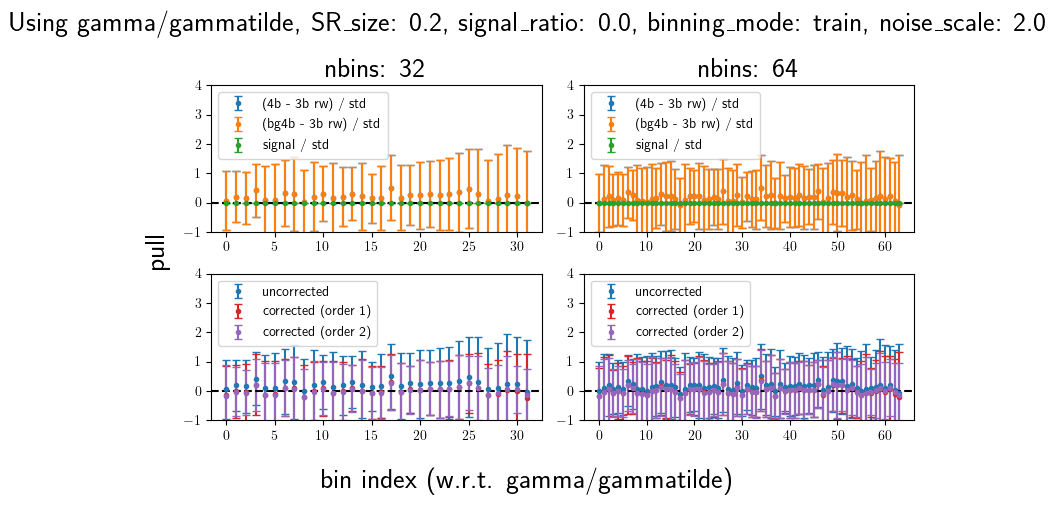

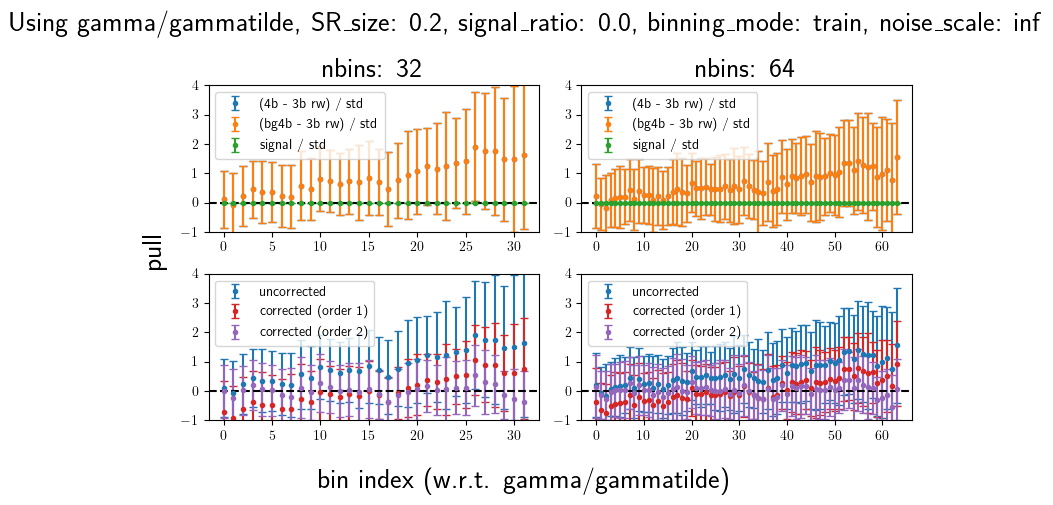

In [6]:
SR_sizes = [0.2]
signal_ratios = [0.0]
binning_modes = ["train"]
noise_scales = [2.0, np.inf]

for SR_size in SR_sizes:
    for signal_ratio in signal_ratios:
        for binning_mode in binning_modes:
            for noise_scale in noise_scales:
                fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
                fig.suptitle(f"Using gamma/gammatilde, SR_size: {SR_size}, signal_ratio: {signal_ratio}, binning_mode: {binning_mode}, noise_scale: {noise_scale}")
                fig.supxlabel("bin index (w.r.t. gamma/gammatilde)")
                fig.supylabel("pull")
                tmp_dicts_target = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                            and d["signal_ratio"] == signal_ratio
                            and d["binning_mode"] == binning_mode
                            and d["noise_scale"] == noise_scale]
                
                for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                    tmp_dicts = [d for d in tmp_dicts_target if d["nbins"] == nbins]
                    
                    pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                    pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                    
                    pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    
                    pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                    pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                    
                    pull_mean_corrected_1 = np.mean([d["pull_o1"] for d in tmp_dicts], axis=0)
                    pull_std_corrected_1 = np.std([d["pull_o1"] for d in tmp_dicts], axis=0)
                    
                    pull_mean_corrected_2 = np.mean([d["pull_o2"] for d in tmp_dicts], axis=0)
                    pull_std_corrected_2 = np.std([d["pull_o2"] for d in tmp_dicts], axis=0)
                    
                    
                    current_ax_0 = ax[0, ax_idx]
                    current_ax_0.set_title(f"nbins: {nbins}")
                    bins = np.arange(nbins)
                    current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
                    current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[1])
                    current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[2])
                    current_ax_0.axhline(0, color="black", linestyle="--")
                    current_ax_0.legend()
                    current_ax_0.set_ylim(-1, 4)
                    
                    current_ax_1 = ax[1, ax_idx]
                    current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[0])
                    current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[3])
                    current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[4])
                    current_ax_1.axhline(0, color="black", linestyle="--")
                    current_ax_1.legend()
                    current_ax_1.set_ylim(-1, 4)
                    
                plt.tight_layout()
                plt.show()
                
            colors = plt.get_cmap("tab10").colors

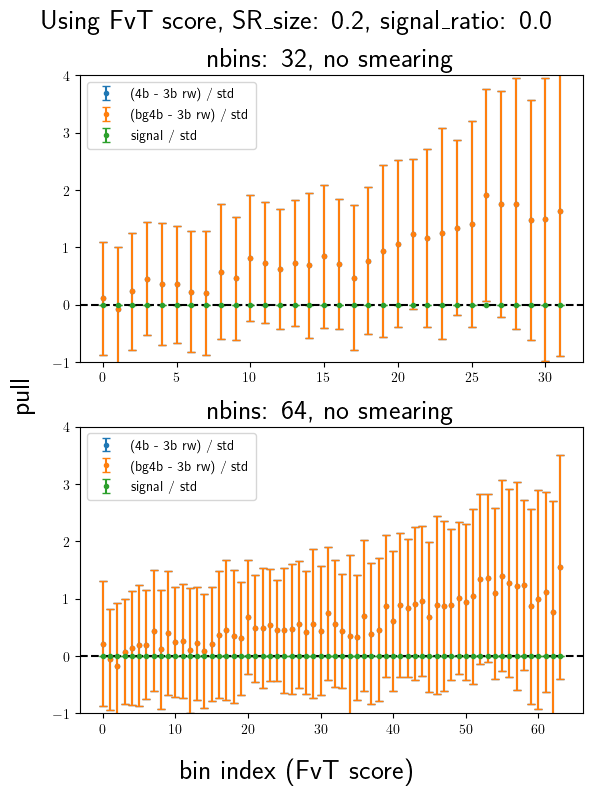

In [23]:
SR_sizes = [0.2]
signal_ratios = [0.0]
binning_modes = ["train"]
noise_scales = [np.inf]

for SR_size in SR_sizes:
    for signal_ratio in signal_ratios:
        for binning_mode in binning_modes:
            fig, ax = plt.subplots(len(nbins_list), 1, figsize=(6, len(nbins_list) * 4))
            fig.suptitle(f"Using FvT score, SR_size: {SR_size}, signal_ratio: {signal_ratio}")
            fig.supxlabel("bin index (FvT score)")
            fig.supylabel("pull")
            
            colors = plt.get_cmap("tab10").colors
            
            for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                for noise_idx, noise_scale in enumerate(noise_scales):
                    current_ax = ax[ax_idx]
                    smearing_str = "no smearing" if noise_scale == np.inf else f"smearing: {noise_scale}"
                    current_ax.set_title(f"nbins: {nbins}, {smearing_str}")
                    bins = np.arange(nbins)
                    
                    tmp_dicts = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                                and d["signal_ratio"] == signal_ratio
                                and d["binning_mode"] == binning_mode
                                and d["noise_scale"] == noise_scale
                                and d["nbins"] == nbins]
                    
                    pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                    pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                    
                    pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    
                    pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                    pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                    
                    current_ax.errorbar(bins, pull_mean, yerr=pull_std, 
                                      label="(4b - 3b rw) / std", 
                                      capsize=3, fmt="o", color=colors[0])
                    current_ax.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, 
                                      label="(bg4b - 3b rw) / std", 
                                      capsize=3, fmt="o", color=colors[1])
                    current_ax.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, 
                                      label="signal / std", 
                                      capsize=3, fmt="o", color=colors[2])
                    
                    current_ax.axhline(0, color="black", linestyle="--")
                    current_ax.legend()
                    current_ax.set_ylim(-1, 4)
                
            plt.tight_layout()
            plt.show()

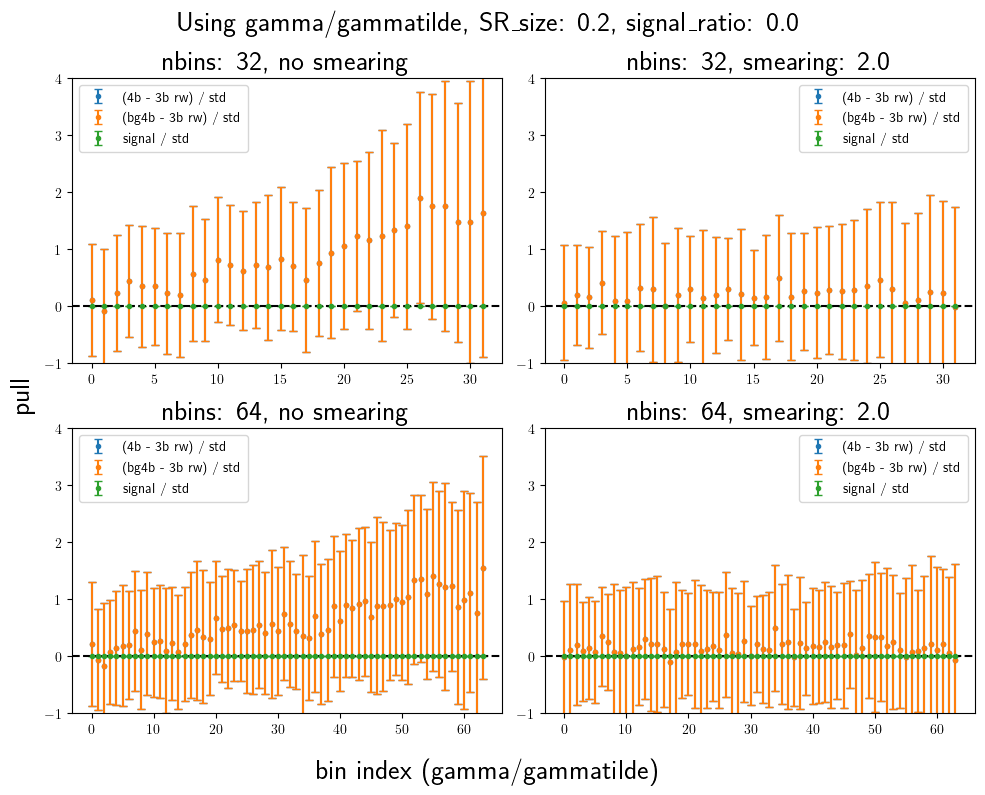

In [7]:
SR_sizes = [0.2]
signal_ratios = [0.0]
binning_modes = ["train"]
noise_scales = [np.inf, 2.0]

for SR_size in SR_sizes:
    for signal_ratio in signal_ratios:
        for binning_mode in binning_modes:
            fig, ax = plt.subplots(len(nbins_list), 2, figsize=(10, len(nbins_list) * 4))
            fig.suptitle(f"Using gamma/gammatilde, SR_size: {SR_size}, signal_ratio: {signal_ratio}")
            fig.supxlabel("bin index (gamma/gammatilde)")
            fig.supylabel("pull")
            
            colors = plt.get_cmap("tab10").colors
            
            for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                for noise_idx, noise_scale in enumerate(noise_scales):
                    current_ax = ax[ax_idx, noise_idx] if len(nbins_list) > 1 else ax[noise_idx]
                    smearing_str = "no smearing" if noise_scale == np.inf else f"smearing: {noise_scale}"
                    current_ax.set_title(f"nbins: {nbins}, {smearing_str}")
                    bins = np.arange(nbins)
                    
                    tmp_dicts = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                                and d["signal_ratio"] == signal_ratio
                                and d["binning_mode"] == binning_mode
                                and d["noise_scale"] == noise_scale
                                and d["nbins"] == nbins]
                    
                    pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                    pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                    
                    pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    
                    pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                    pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                    
                    current_ax.errorbar(bins, pull_mean, yerr=pull_std, 
                                      label="(4b - 3b rw) / std", 
                                      capsize=3, fmt="o", color=colors[0])
                    current_ax.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, 
                                      label="(bg4b - 3b rw) / std", 
                                      capsize=3, fmt="o", color=colors[1])
                    current_ax.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, 
                                      label="signal / std", 
                                      capsize=3, fmt="o", color=colors[2])
                    
                    current_ax.axhline(0, color="black", linestyle="--")
                    current_ax.legend()
                    current_ax.set_ylim(-1, 4)
                
            plt.tight_layout()
            plt.show()

Processing hash 1/2


/tmp/ipykernel_2960735/1202281353.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2


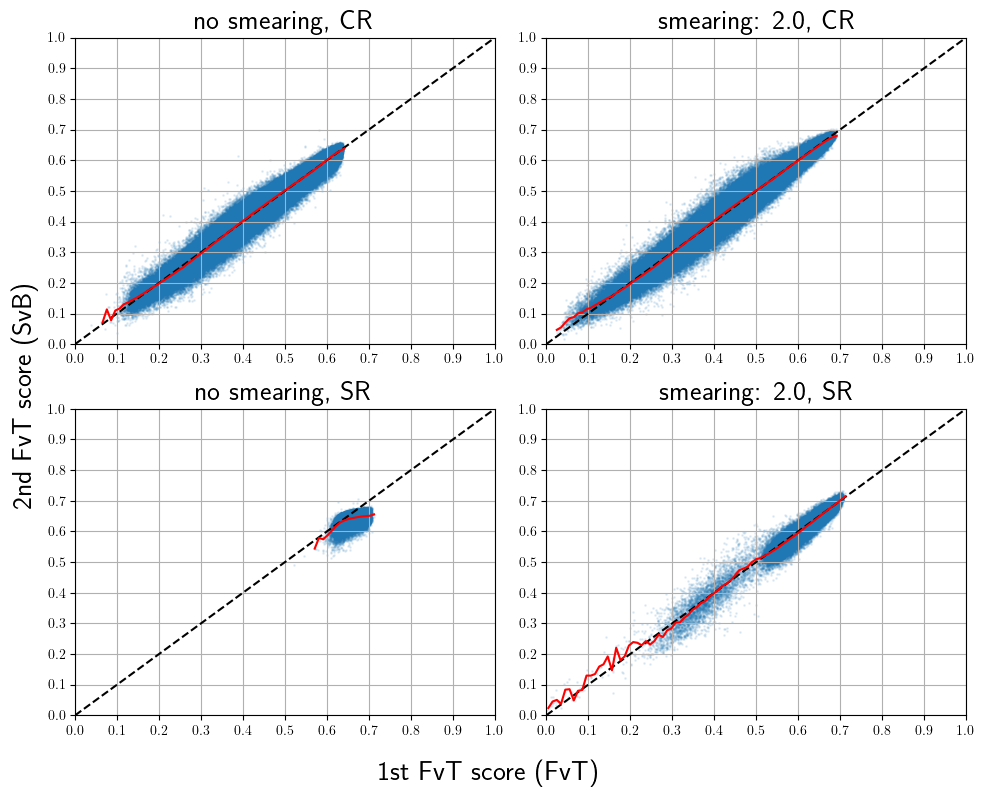

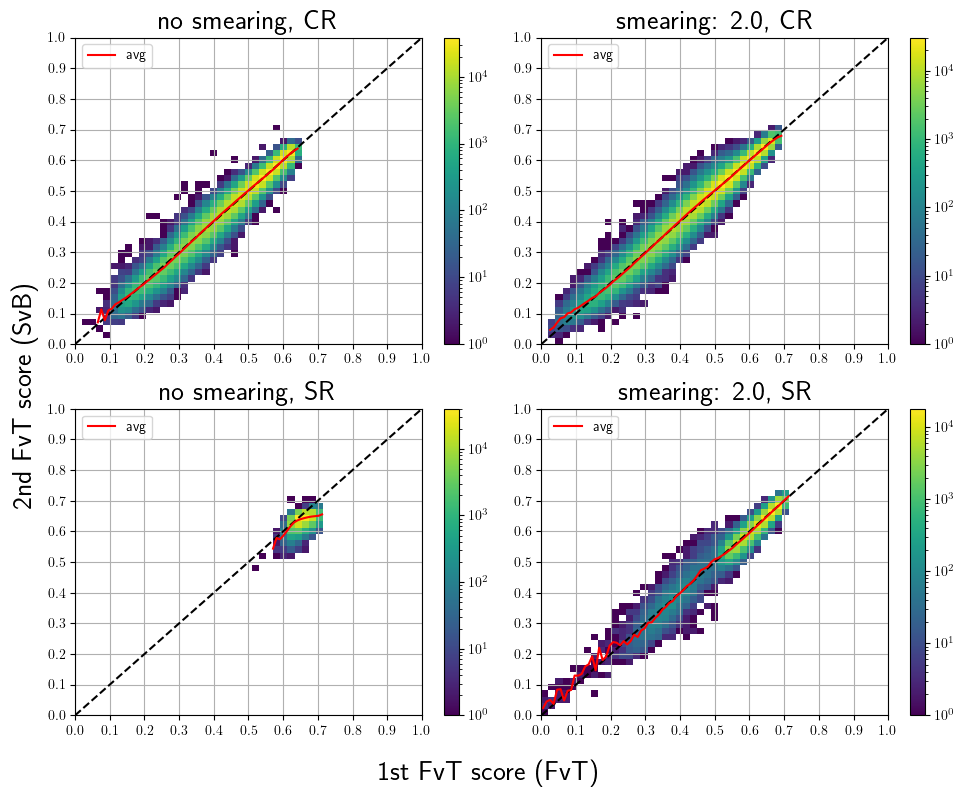

Processing hash 1/2


/tmp/ipykernel_2960735/1202281353.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2


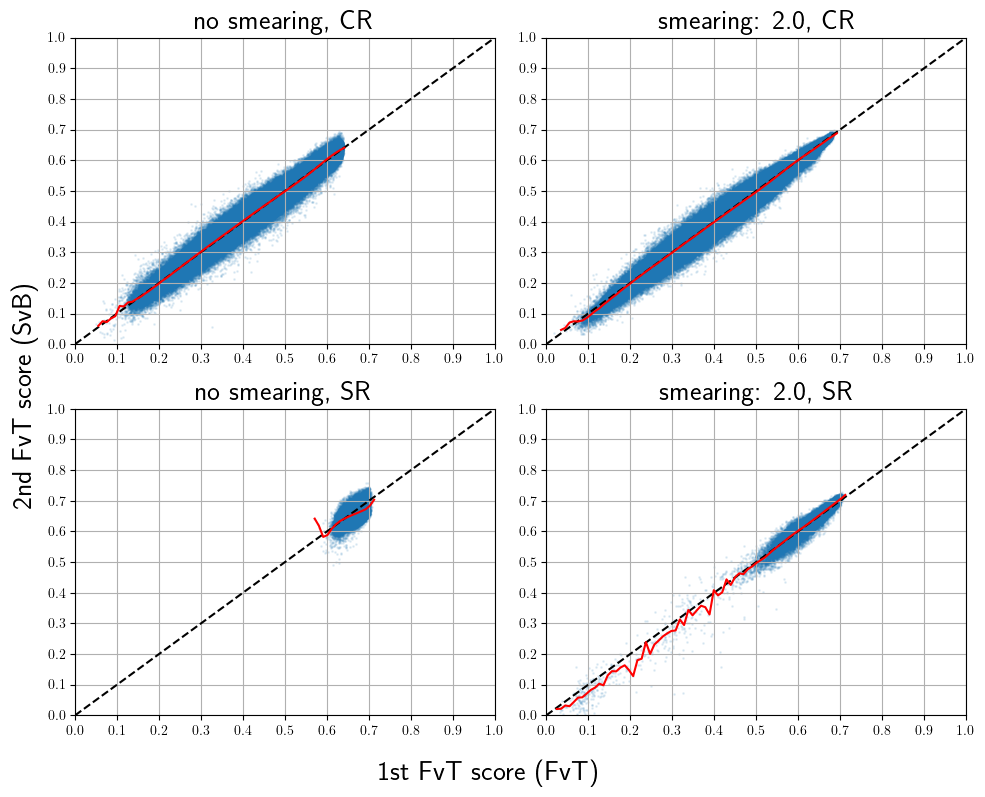

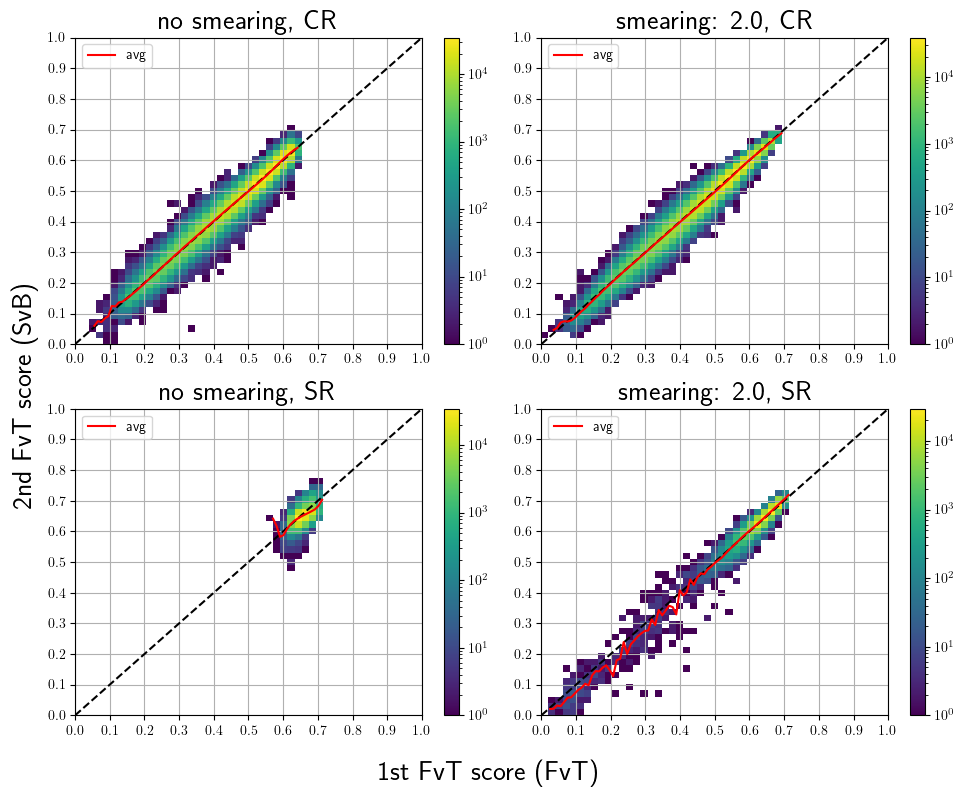

Processing hash 1/2


/tmp/ipykernel_2960735/1202281353.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2


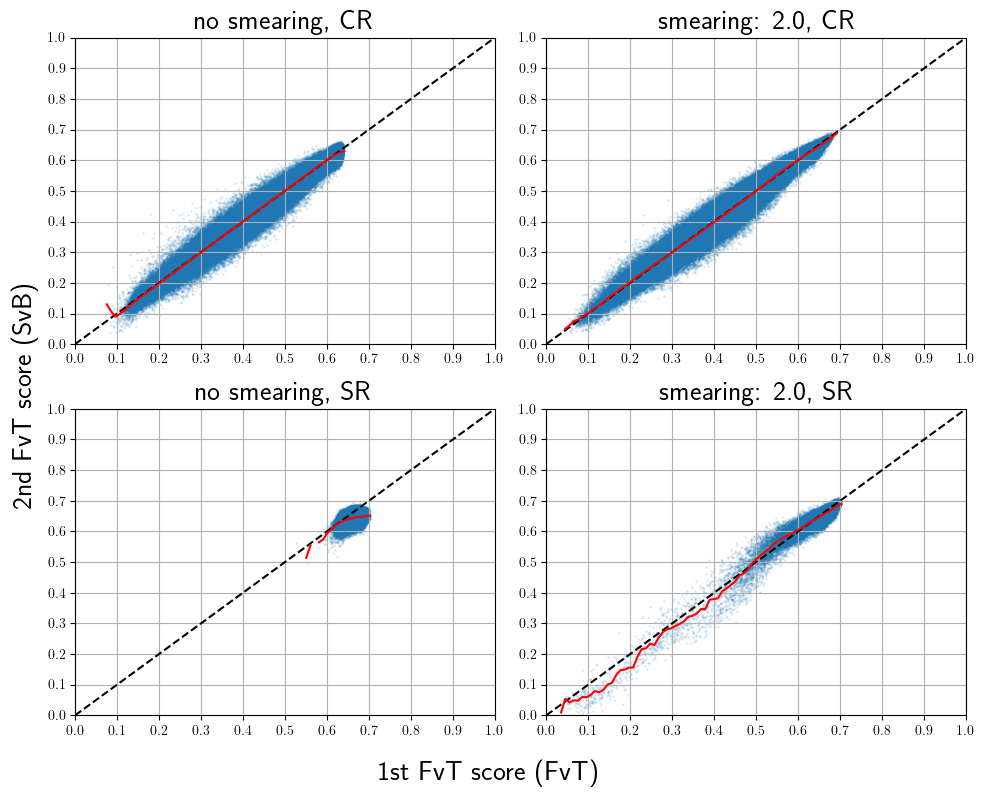

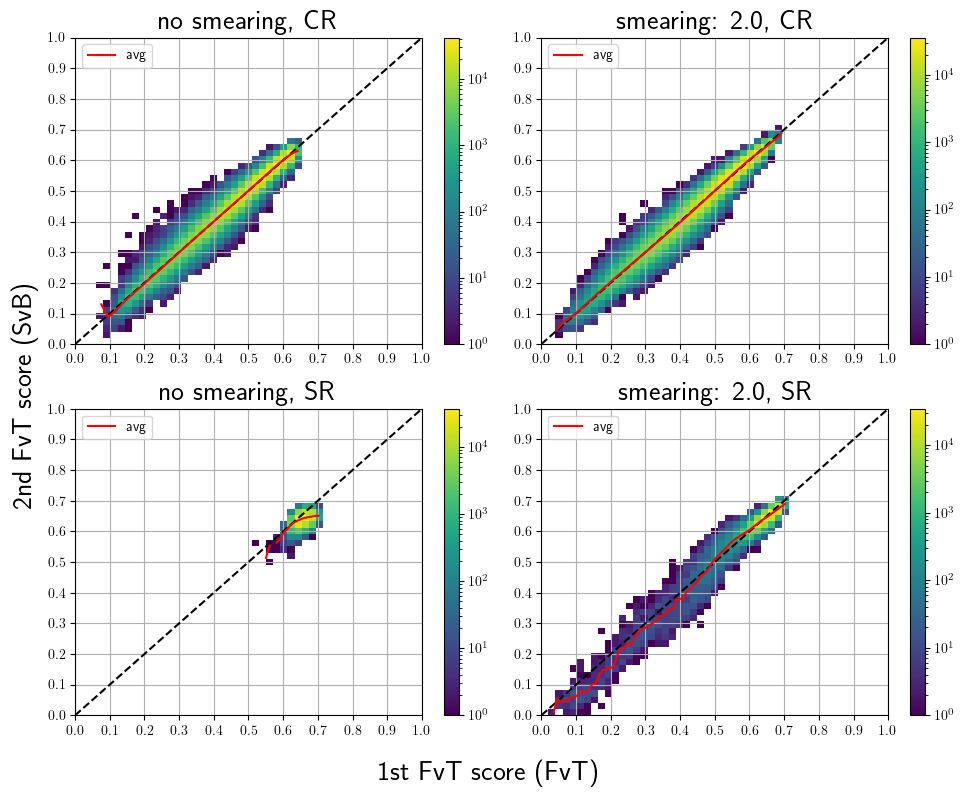

Processing hash 1/2


/tmp/ipykernel_2960735/1202281353.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2


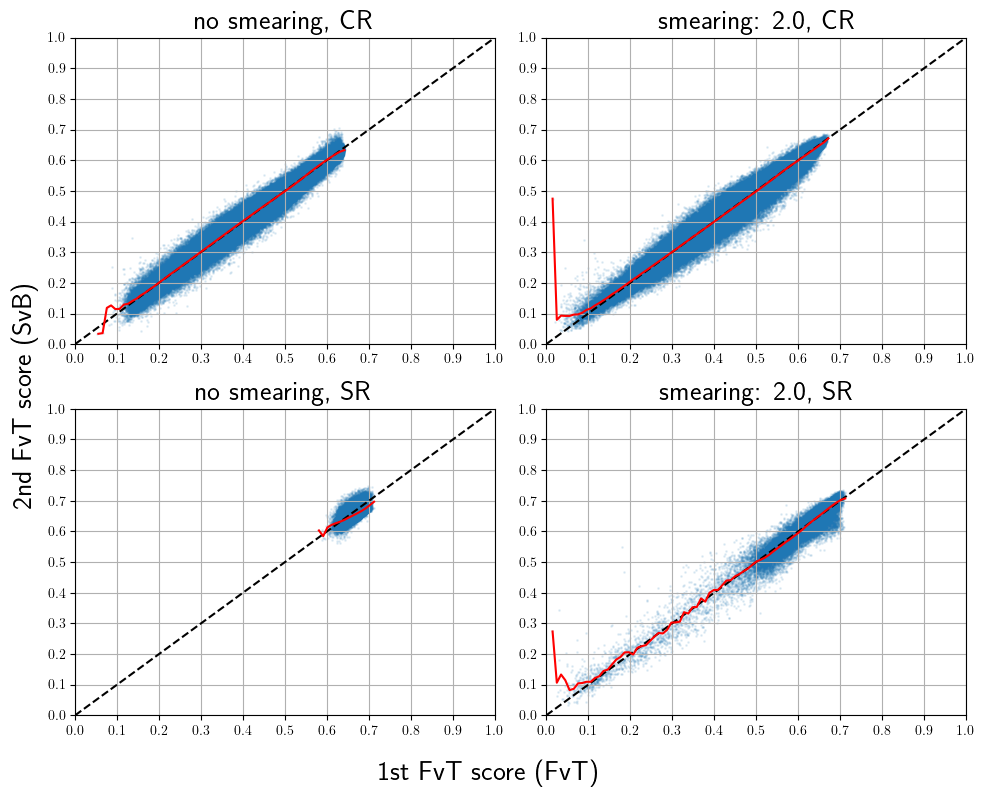

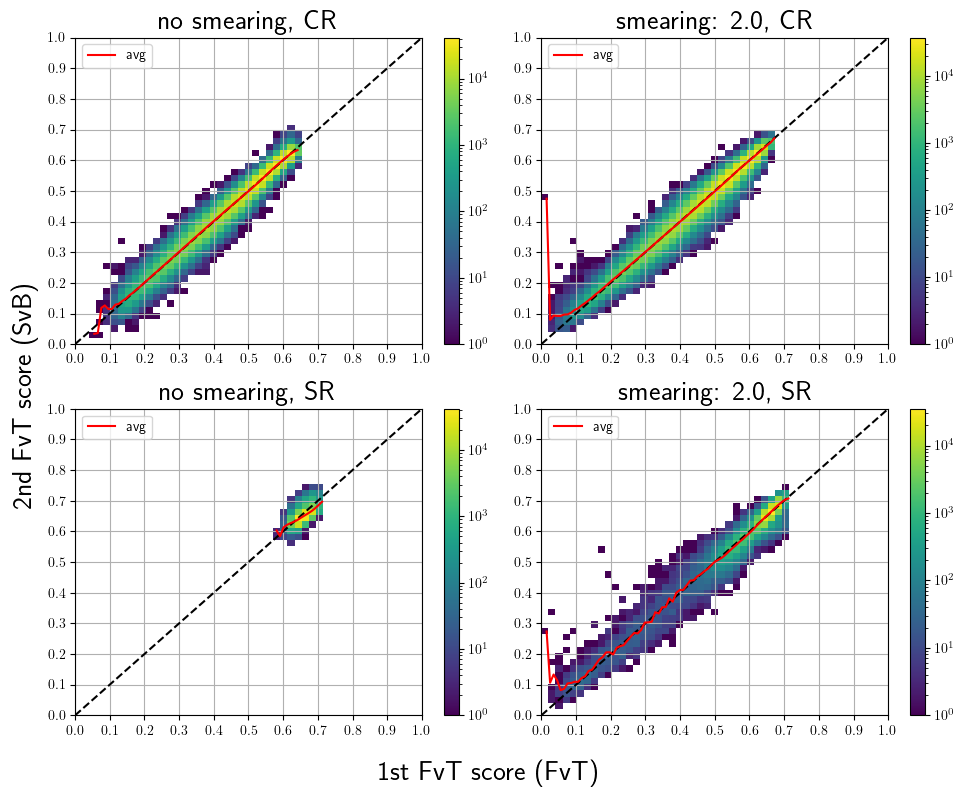

Processing hash 1/2


/tmp/ipykernel_2960735/1202281353.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2


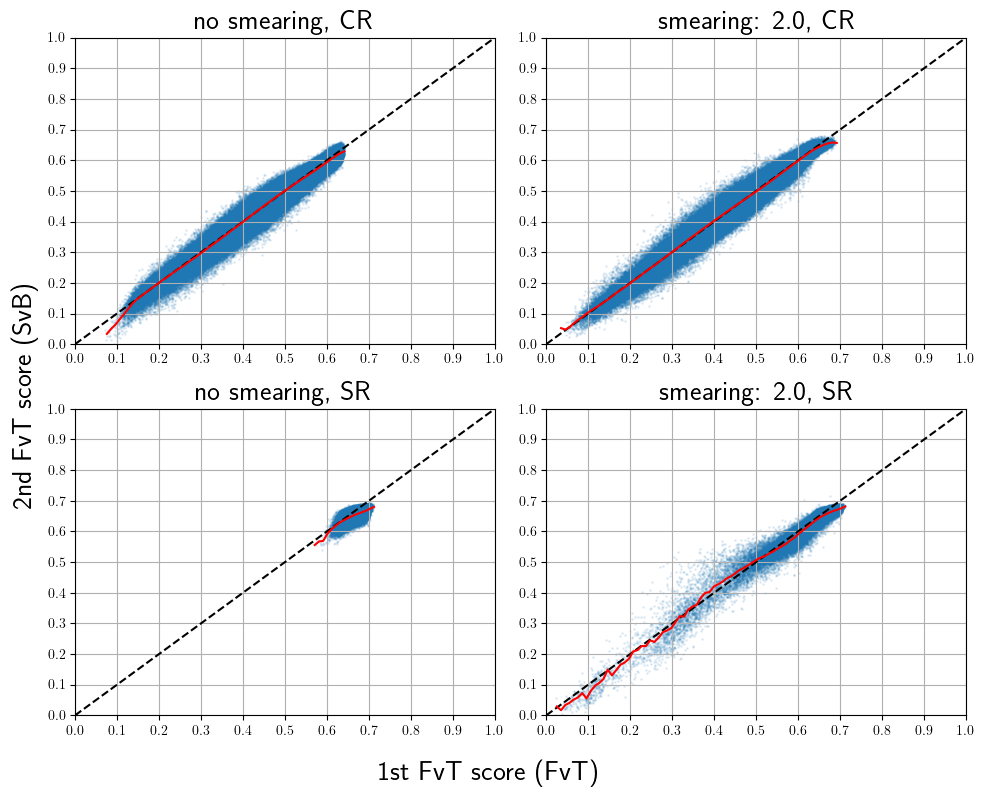

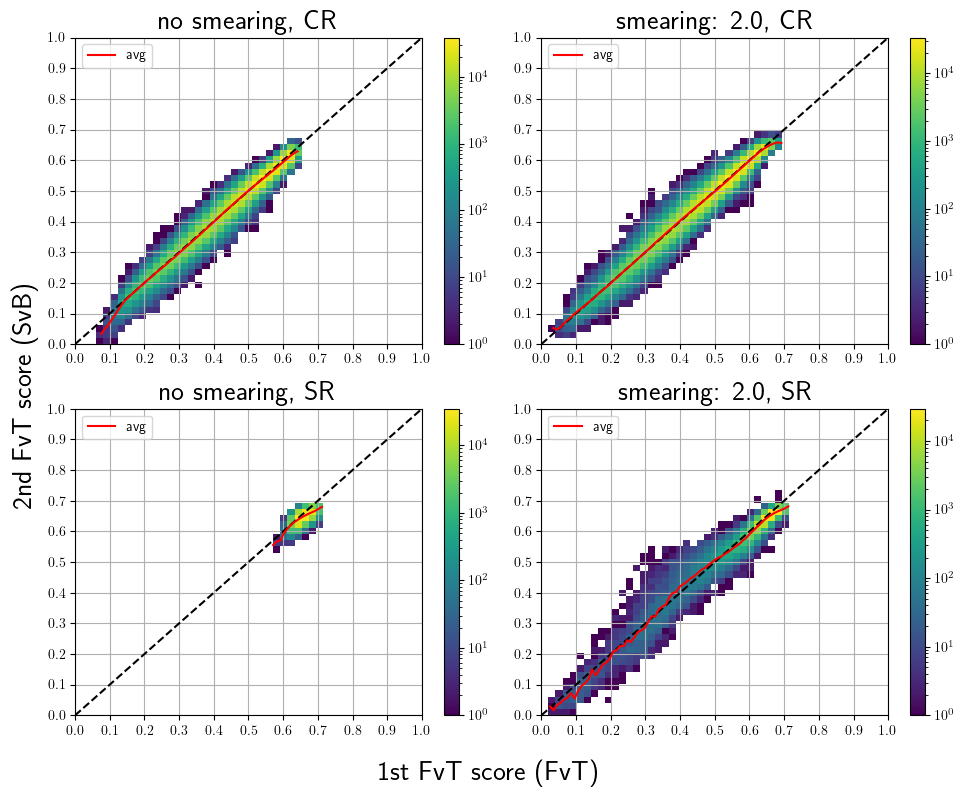

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
from matplotlib.colors import LogNorm
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut

# Constants
NBINS = 10
SIGNAL_RATIO = 0.0
SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_training_info(experiment_name: str, signal_ratio: float, seed: int, allowed_noise_scales: List[float]) -> List[str]:
    """Find training info hashes based on experiment parameters."""
    hashes = TrainingInfo.find({
        "experiment_name": experiment_name, 
        "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed, 
        "signal_region": lambda x: x["4b_in_SR"] == 0.2
    })
    noise_scales = get_noise_scales(hashes)
    return [hash_ for hash_, noise_scale in zip(hashes, noise_scales) if noise_scale in allowed_noise_scales]

def get_noise_scales(hashes: List[str]) -> List[float]:
    """Extract noise scales from training info hashes."""
    noise_scales = []
    for hash_ in hashes:
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        smeared_tinfo = TrainingInfo.load(CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"][0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        noise_scales.append(noise_scale)
    return noise_scales

def sort_hashes_by_noise_scale(hashes: List[str], noise_scales: List[float]) -> List[str]:
    """Sort hashes by their corresponding noise scales."""
    return [x for _, x in sorted(zip(noise_scales, hashes), key=lambda pair: pair[0])]

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

def calculate_base_fvt_scores(SR_stats_hashes: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate base FvT scores for training and test sets."""
    base_fvt_scores_tst = []
    base_fvt_scores_train = []
    
    for hash_ in SR_stats_hashes:
        smeared_tinfo = TrainingInfo.load(hash_)
        base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
        
        # Test scores
        base_fvt_logits_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
        base_fvt_score_tst = np.exp(base_fvt_logits_tst) / (np.exp(base_fvt_logits_tst) + 1)
        base_fvt_scores_tst.append(base_fvt_score_tst)
        
        # Training scores
        base_fvt_logits_train = base_tinfo.aux_info["base_fvt_logit_train"]
        base_fvt_score_train = np.exp(base_fvt_logits_train) / (np.exp(base_fvt_logits_train) + 1)
        base_fvt_scores_train.append(base_fvt_score_train)
    
    return np.mean(base_fvt_scores_tst, axis=0), np.mean(base_fvt_scores_train, axis=0)

def create_figure_with_subplots(rows: int = 3, cols: int = 2, figsize: Tuple[int, int] = (10, 9), 
                              title: Optional[str] = None, 
                              xlabel: Optional[str] = None, 
                              ylabel: Optional[str] = None) -> Tuple[plt.Figure, np.ndarray]:
    """Create a figure with subplots and common labels."""
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)
    if title:
        fig.suptitle(title)
    if xlabel:
        fig.supxlabel(xlabel)
    if ylabel:
        fig.supylabel(ylabel)
    return fig, axs

def compute_avg_fvt_score(base_fvt_scores: np.ndarray, fvt_scores: np.ndarray) -> np.ndarray:
    bins = np.linspace(0, 1, 100)
    hist_fvt, _ = np.histogram(base_fvt_scores, bins)
    hist_fvt_wgt, _ = np.histogram(base_fvt_scores, bins, weights=fvt_scores)
    midpoints = (bins[1:] + bins[:-1]) / 2
    return midpoints, hist_fvt_wgt / hist_fvt

def scatter_fvt_fvt(ax: plt.Axes, base_fvt_scores: np.ndarray, fvt_scores: np.ndarray, 
                 fvt_avg: np.ndarray, midpoints: np.ndarray):
    # enable grid
    # set x and y ticks to 0.1, 0.2, ..., 1
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--")
    ax.scatter(base_fvt_scores, fvt_scores, alpha=0.1, s=1)
    ax.plot(midpoints, fvt_avg, color="red")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
def hist_fvt_fvt(ax: plt.Axes, base_fvt_scores: np.ndarray, fvt_scores: np.ndarray, 
                 fvt_avg: np.ndarray, midpoints: np.ndarray):
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    bins = np.linspace(0, 1, 50)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--")
    h = ax.hist2d(base_fvt_scores, fvt_scores, bins=(bins, bins), 
                  norm=LogNorm())
    plt.colorbar(h[3], ax=ax)
    ax.plot(midpoints, fvt_avg, color="red", label="avg")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
def plot_hash_results(hash_: str, 
                    base_fvt_scores_tst: np.ndarray, 
                    events_train: EventsData,
                    events_tst: EventsData, 
                    axs_scatter: plt.Axes, 
                    axs_hist: plt.Axes, 
                    plot_idx: int):
    """Analyze and plot results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    # Get region cuts and indices
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
    )
    CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
    SR_idx = SR_stats_tst >= SR_cut
    
    # Calculate FVT scores
    events_tst_CR = events_tst[CR_idx]
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    fvt_scores_tst_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].numpy()
    
    
    midpoints_cr, fvt_avg_cr = compute_avg_fvt_score(base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR)
    midpoints_sr, fvt_avg_sr = compute_avg_fvt_score(base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR)
    
    smearing_str = "no smearing" if noise_scale == np.inf else f"smearing: {noise_scale}"
    axs_scatter[0, plot_idx].set_title(f"{smearing_str}, CR")
    scatter_fvt_fvt(axs_scatter[0, plot_idx], base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR, fvt_avg_cr, midpoints_cr)
    
    axs_scatter[1, plot_idx].set_title(f"{smearing_str}, SR")
    scatter_fvt_fvt(axs_scatter[1, plot_idx], base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR, fvt_avg_sr, midpoints_sr)
    
    axs_hist[0, plot_idx].set_title(f"{smearing_str}, CR")
    hist_fvt_fvt(axs_hist[0, plot_idx], base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR, fvt_avg_cr, midpoints_cr)
    
    axs_hist[1, plot_idx].set_title(f"{smearing_str}, SR")
    hist_fvt_fvt(axs_hist[1, plot_idx], base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR, fvt_avg_sr, midpoints_sr)
    
    for ax_hist in axs_hist[:, plot_idx]:
        ax_hist.legend()
    
    
allowed_noise_scales = [np.inf, 2.0]
for seed in [5, 10, 15, 20, 25]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    hashes = hashes[::-1]
    noise_scales = noise_scales[::-1]
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    base_fvt_scores_tst, base_fvt_scores_train = calculate_base_fvt_scores(SR_stats_hashes)

    fig_scatter, axs_scatter = plt.subplots(len(allowed_noise_scales), 2, figsize=(10, 4 * len(allowed_noise_scales)))
    fig_scatter.supxlabel("1st FvT score (FvT)")
    fig_scatter.supylabel("2nd FvT score (SvB)")
    
    fig_hist, axs_hist = plt.subplots(len(allowed_noise_scales), 2, figsize=(10, 4 * len(allowed_noise_scales)))
    fig_hist.supxlabel("1st FvT score (FvT)")
    fig_hist.supylabel("2nd FvT score (SvB)")
    
    # sort hashes by noise scale
    
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        plot_hash_results(hash_, base_fvt_scores_tst, events_train, events_tst, axs_scatter, axs_hist, i)
    
    # Display results
    for fig in [fig_scatter, fig_hist]: 
        fig.tight_layout()
    plt.show()

Processing hash 1/2
noise_scale = 2.0
Corr all: 0.862
Corr CR: 0.868
Corr SR: -0.161


/tmp/ipykernel_2960735/1064876907.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt
2025-07-09 22:45:12,773 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:45:12,774 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing hash 2/2
noise_scale = inf
Corr all: 0.981
Corr CR: 0.977
Corr SR: 0.382


2025-07-09 22:45:17,870 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:45:17,871 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


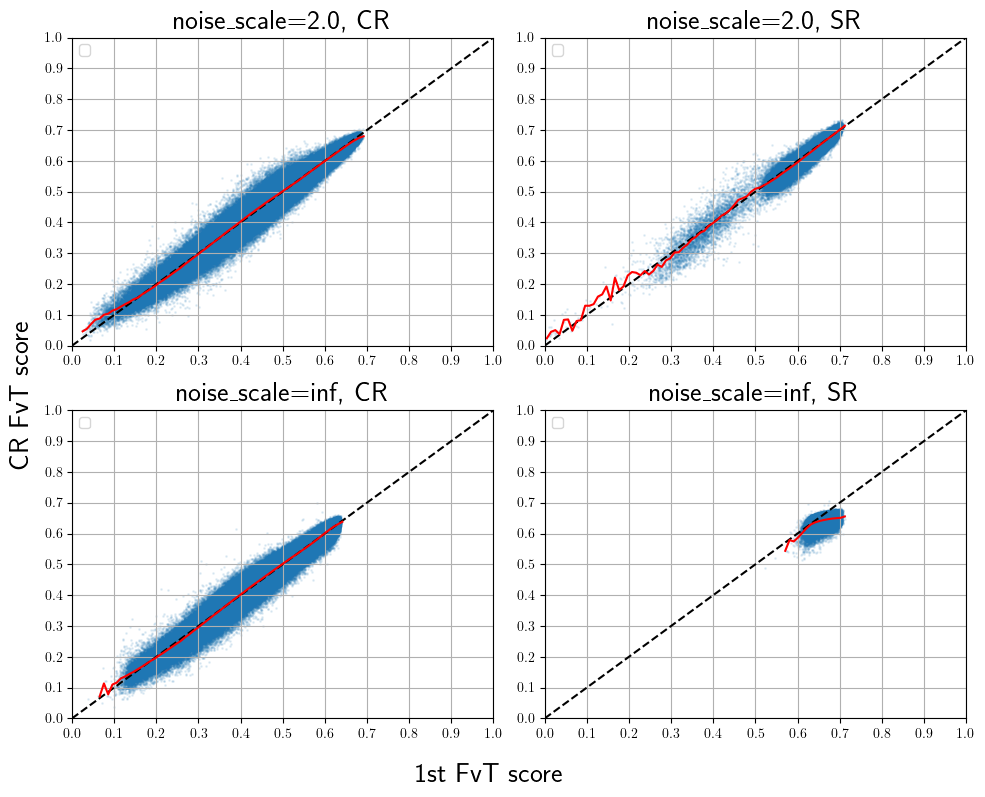

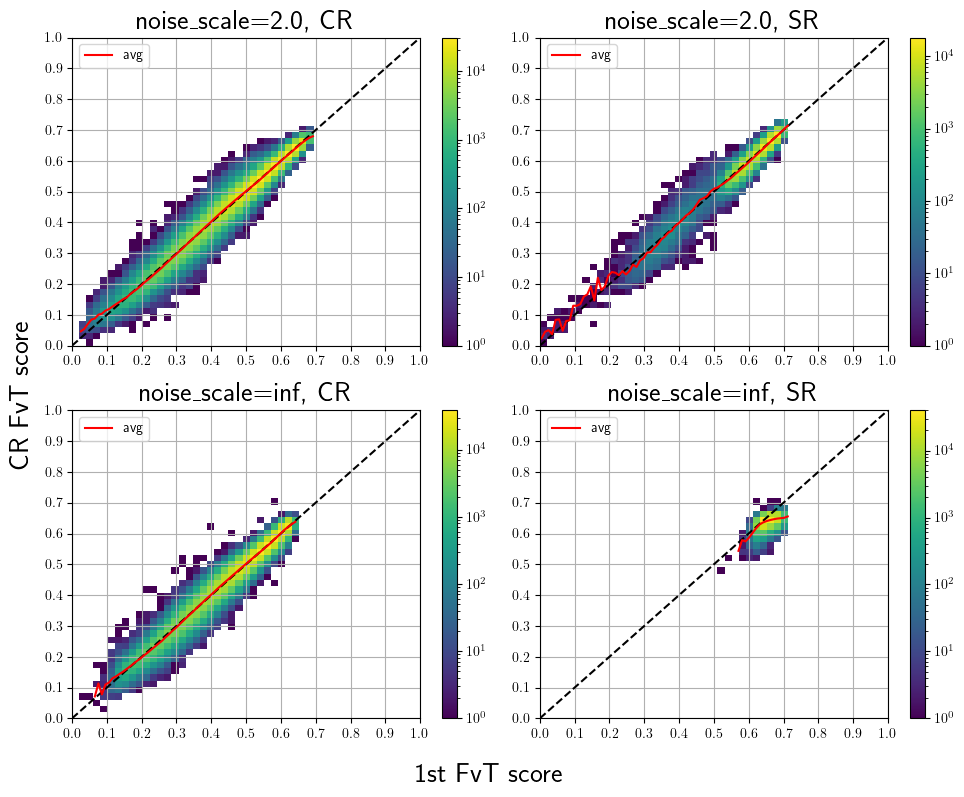

Processing hash 1/2
noise_scale = 2.0
Corr all: 0.893
Corr CR: 0.875
Corr SR: 0.010


/tmp/ipykernel_2960735/1064876907.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt
2025-07-09 22:45:39,600 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:45:39,601 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing hash 2/2
noise_scale = inf
Corr all: 0.984
Corr CR: 0.979
Corr SR: 0.552


2025-07-09 22:45:44,691 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:45:44,692 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


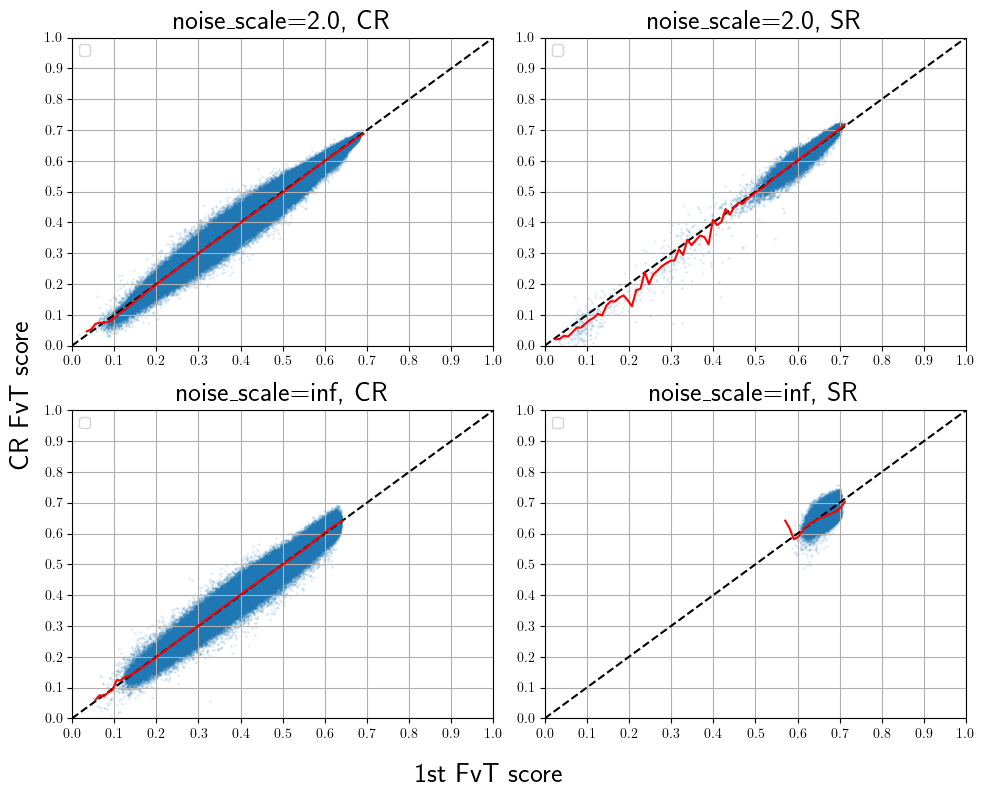

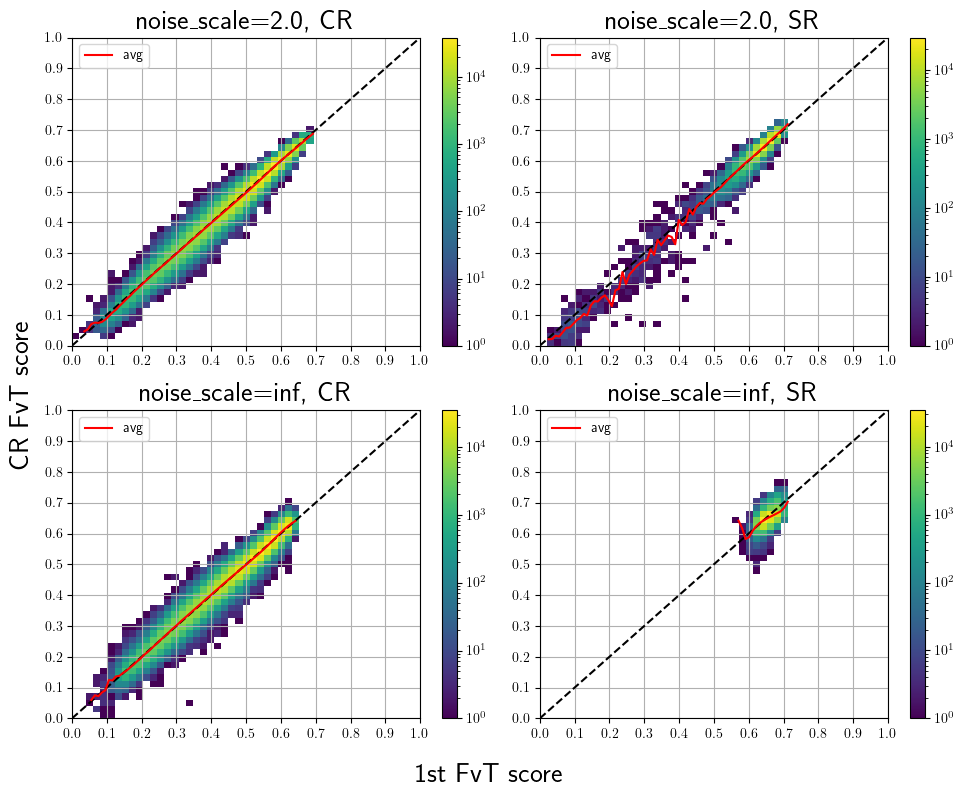

Processing hash 1/2
noise_scale = 2.0
Corr all: 0.887
Corr CR: 0.873
Corr SR: 0.073


/tmp/ipykernel_2960735/1064876907.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt
2025-07-09 22:46:06,372 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:46:06,373 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing hash 2/2
noise_scale = inf
Corr all: 0.984
Corr CR: 0.981
Corr SR: 0.411


2025-07-09 22:46:11,597 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:46:11,598 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


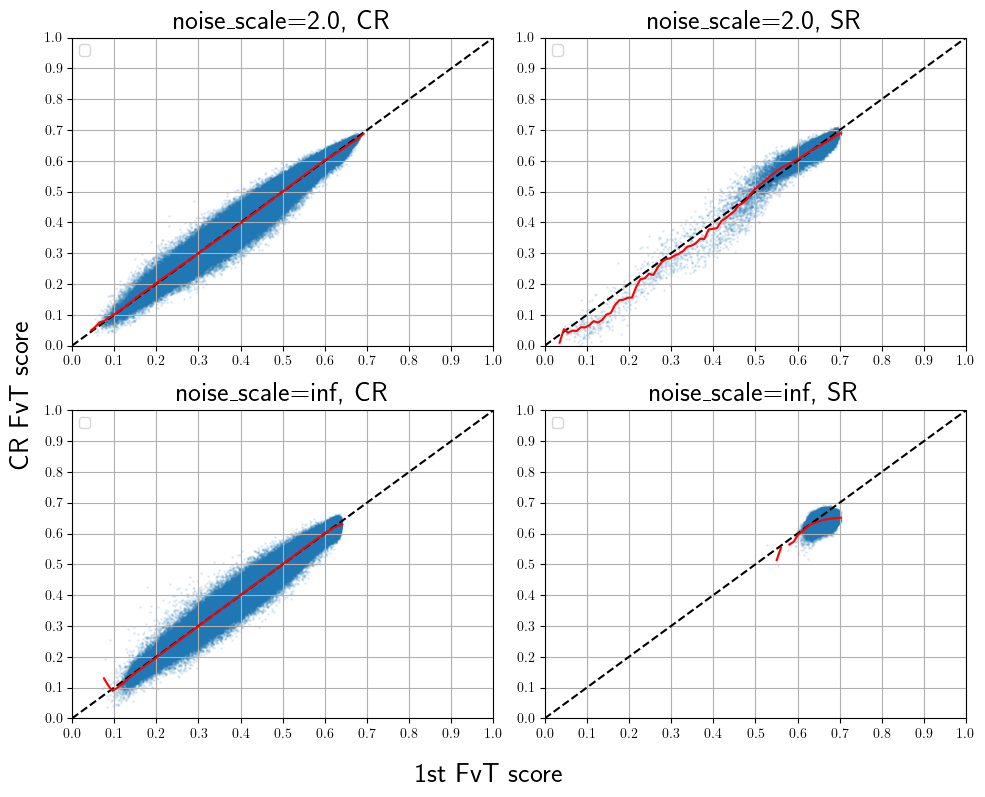

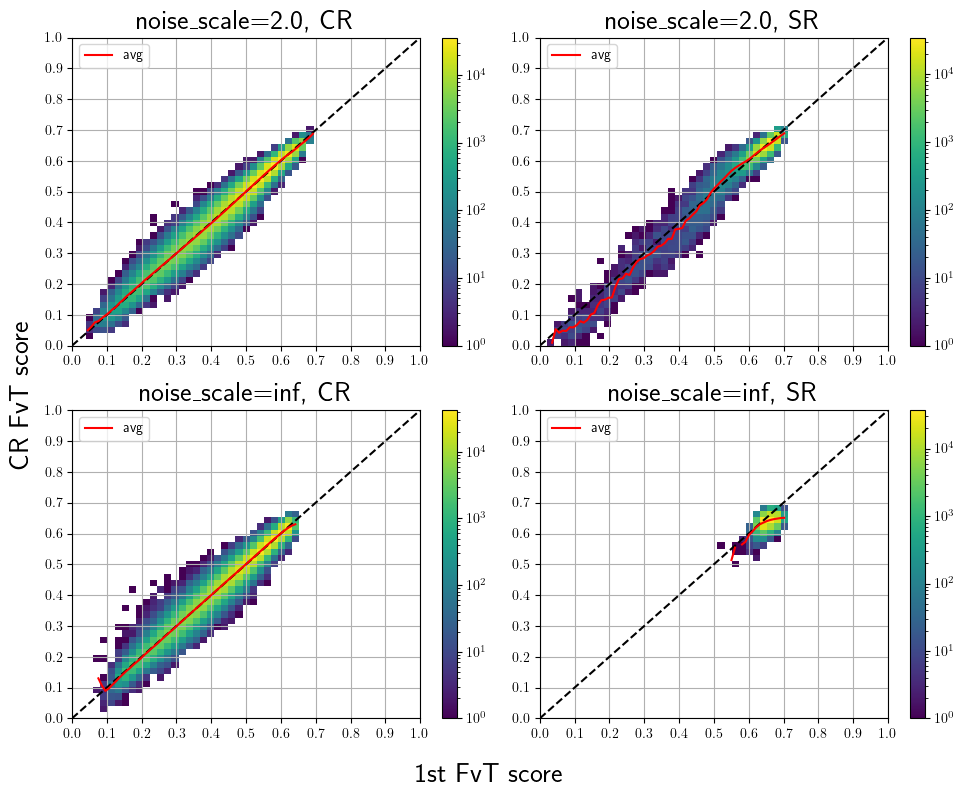

Processing hash 1/2
noise_scale = 2.0
Corr all: 0.840
Corr CR: 0.819
Corr SR: 0.001


/tmp/ipykernel_2960735/1064876907.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt
2025-07-09 22:46:33,460 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:46:33,461 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing hash 2/2
noise_scale = inf
Corr all: 0.986
Corr CR: 0.981
Corr SR: 0.744


2025-07-09 22:46:38,534 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:46:38,535 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


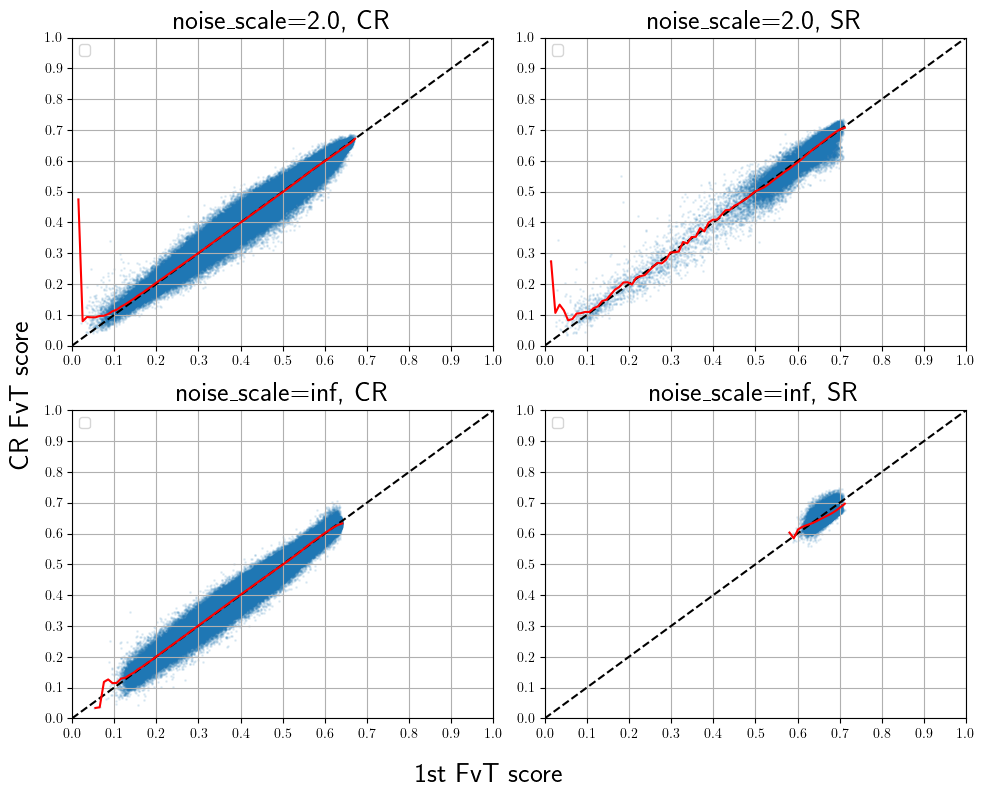

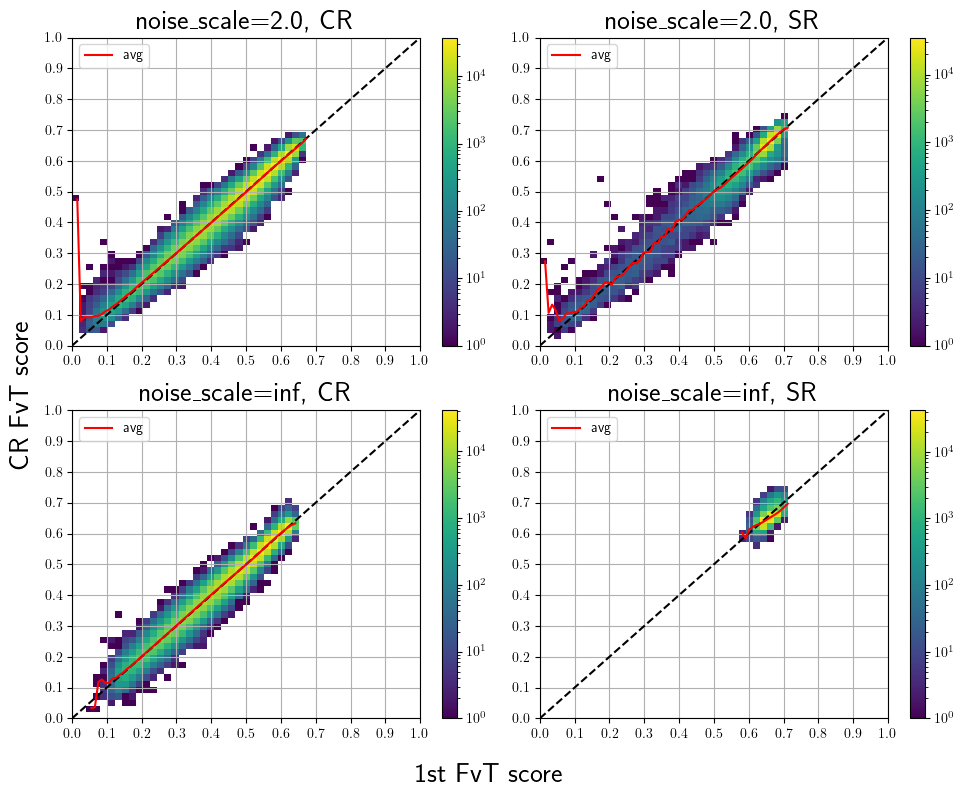

Processing hash 1/2
noise_scale = 2.0
Corr all: 0.844
Corr CR: 0.828
Corr SR: -0.133


/tmp/ipykernel_2960735/1064876907.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt
2025-07-09 22:47:01,262 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:47:01,263 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing hash 2/2
noise_scale = inf
Corr all: 0.985
Corr CR: 0.980
Corr SR: 0.658


2025-07-09 22:47:06,350 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2025-07-09 22:47:06,351 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


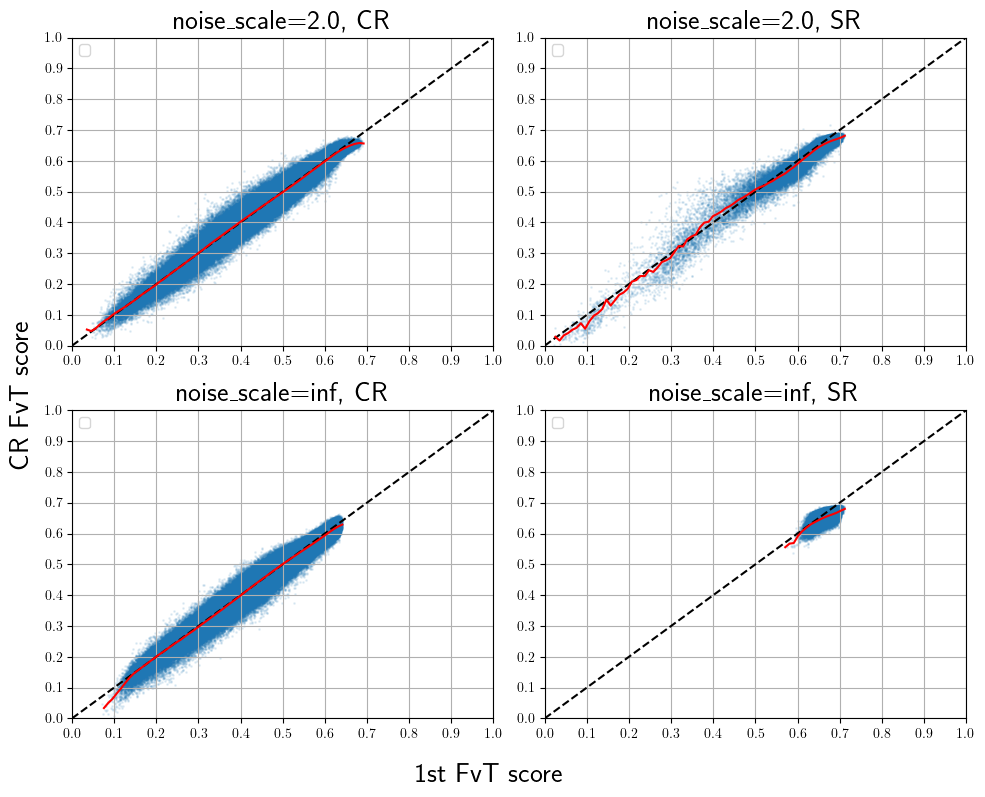

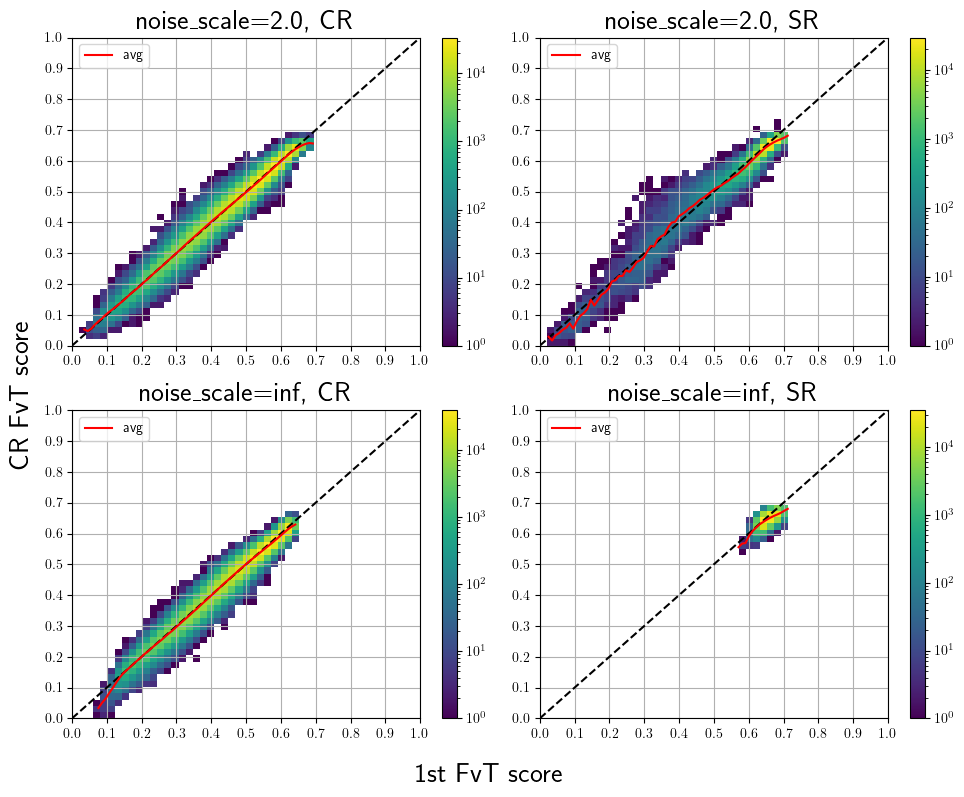

In [18]:
allowed_noise_scales = [np.inf, 2.0]
for seed in [5, 10, 15, 20, 25]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    base_fvt_scores_tst, base_fvt_scores_train = calculate_base_fvt_scores(SR_stats_hashes)

    fig_scatter, axs_scatter = plt.subplots(len(allowed_noise_scales), 2, figsize=(10, 4 * len(allowed_noise_scales)))
    fig_scatter.supxlabel("1st FvT score")
    fig_scatter.supylabel("CR FvT score")
    
    fig_hist, axs_hist = plt.subplots(len(allowed_noise_scales), 2, figsize=(10, 4 * len(allowed_noise_scales)))
    fig_hist.supxlabel("1st FvT score")
    fig_hist.supylabel("CR FvT score")
    
    # Process each hash
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        plot_hash_results(hash_, base_fvt_scores_tst, events_train, events_tst, axs_scatter, axs_hist, i)
    
    # Display results
    for fig in [fig_scatter, fig_hist]: 
        fig.tight_layout()
    plt.show()

Processing hash 1/2
noise_scale = 2.0
Corr CR: 0.868
Corr SR: -0.161


/tmp/ipykernel_2960735/3104690239.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2
noise_scale = inf
Corr CR: 0.977
Corr SR: 0.382


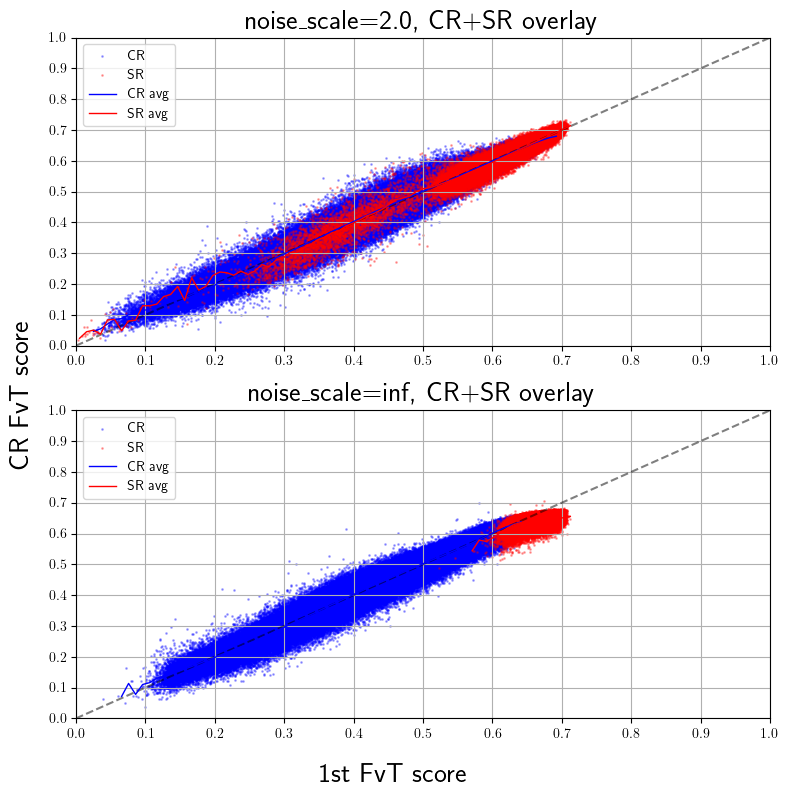

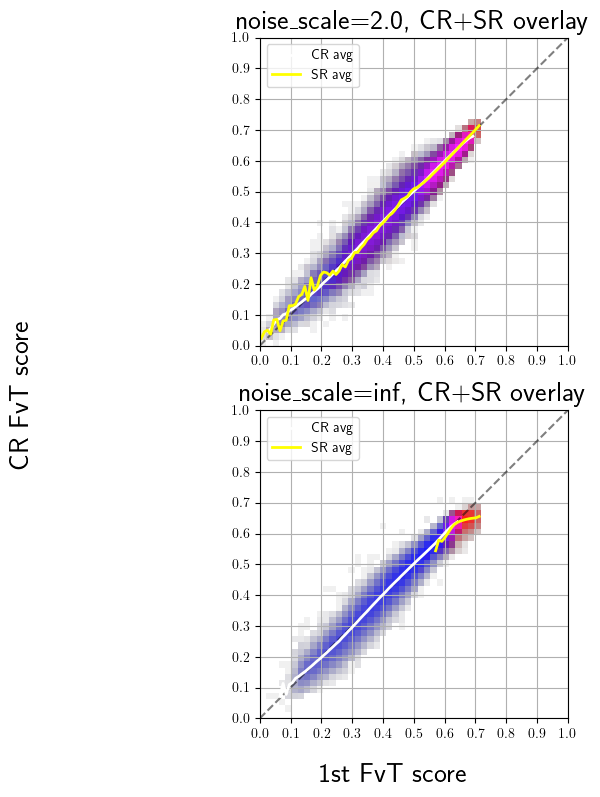

Processing hash 1/2
noise_scale = 2.0
Corr CR: 0.875
Corr SR: 0.010


/tmp/ipykernel_2960735/3104690239.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2
noise_scale = inf
Corr CR: 0.979
Corr SR: 0.552


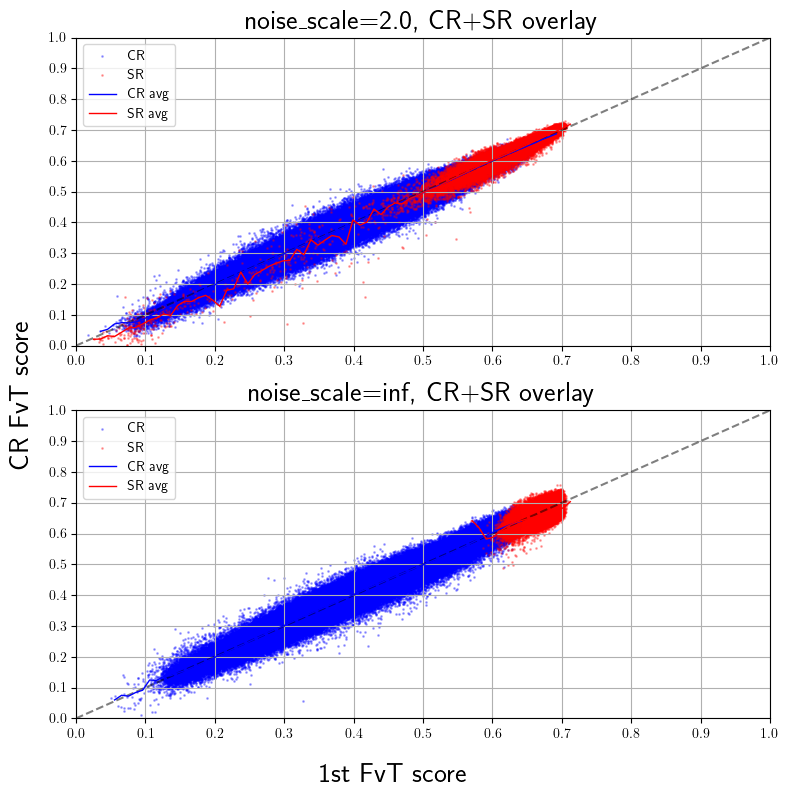

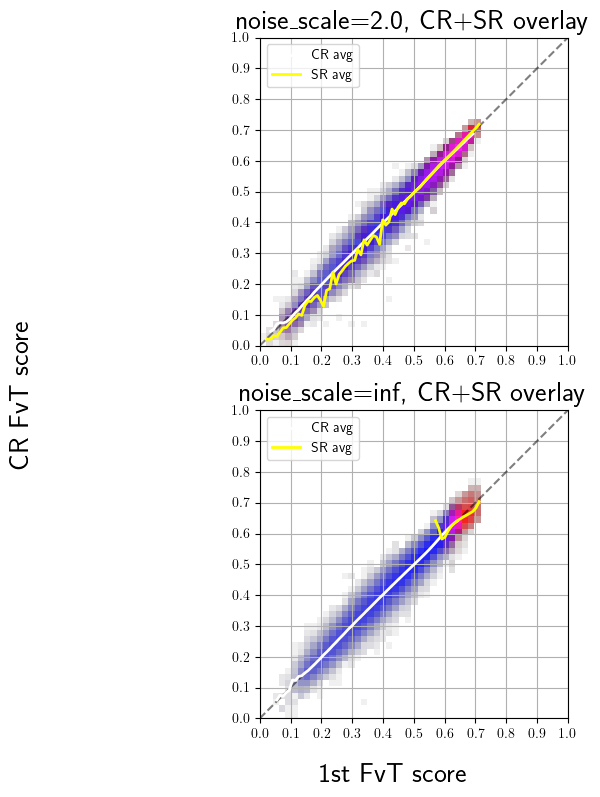

Processing hash 1/2
noise_scale = 2.0
Corr CR: 0.873
Corr SR: 0.073


/tmp/ipykernel_2960735/3104690239.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2
noise_scale = inf
Corr CR: 0.981
Corr SR: 0.411


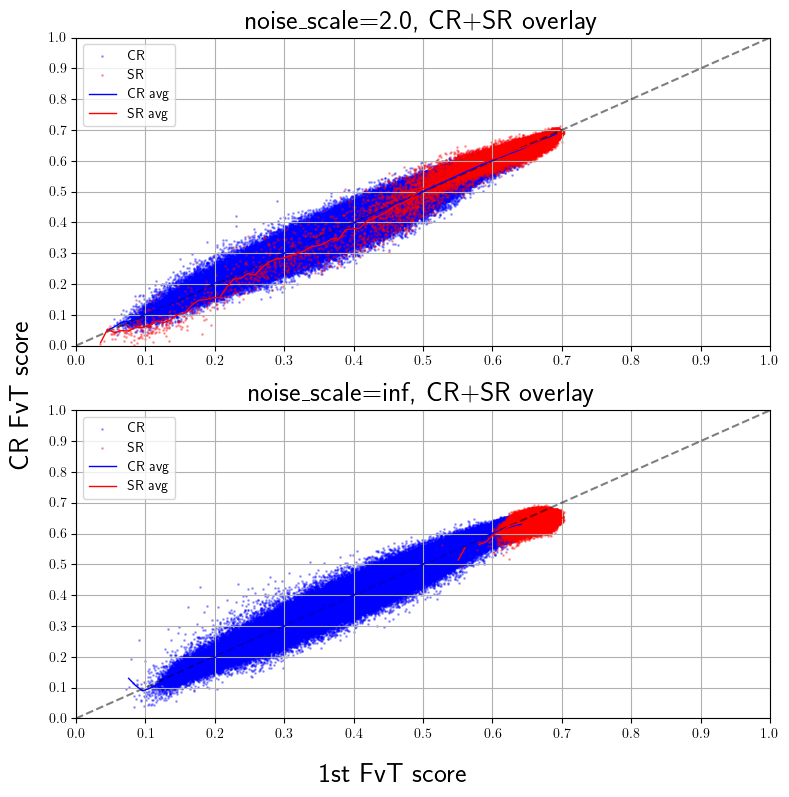

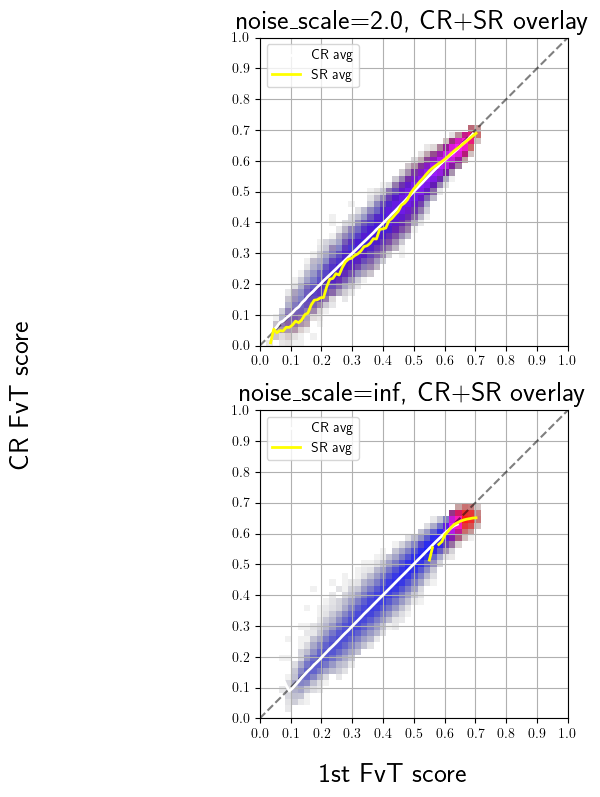

Processing hash 1/2
noise_scale = 2.0
Corr CR: 0.819
Corr SR: 0.001


/tmp/ipykernel_2960735/3104690239.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2
noise_scale = inf
Corr CR: 0.981
Corr SR: 0.744


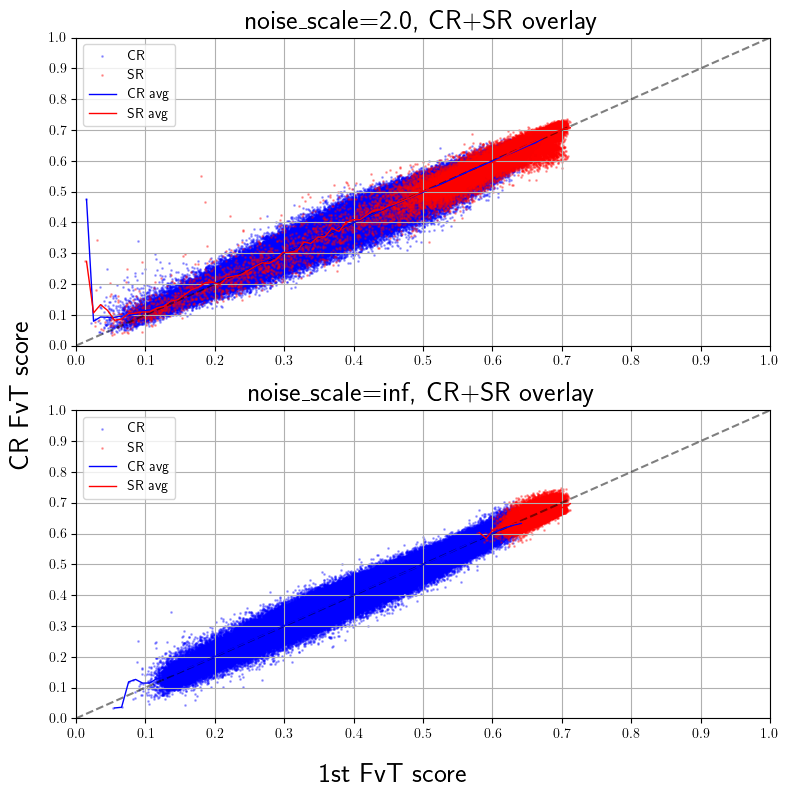

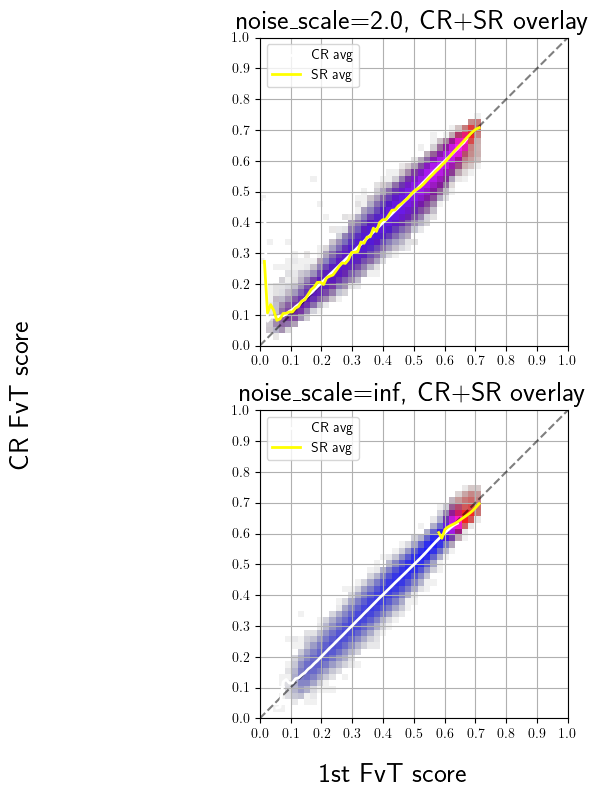

Processing hash 1/2
noise_scale = 2.0
Corr CR: 0.828
Corr SR: -0.133


/tmp/ipykernel_2960735/3104690239.py:99: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/2
noise_scale = inf
Corr CR: 0.980
Corr SR: 0.658


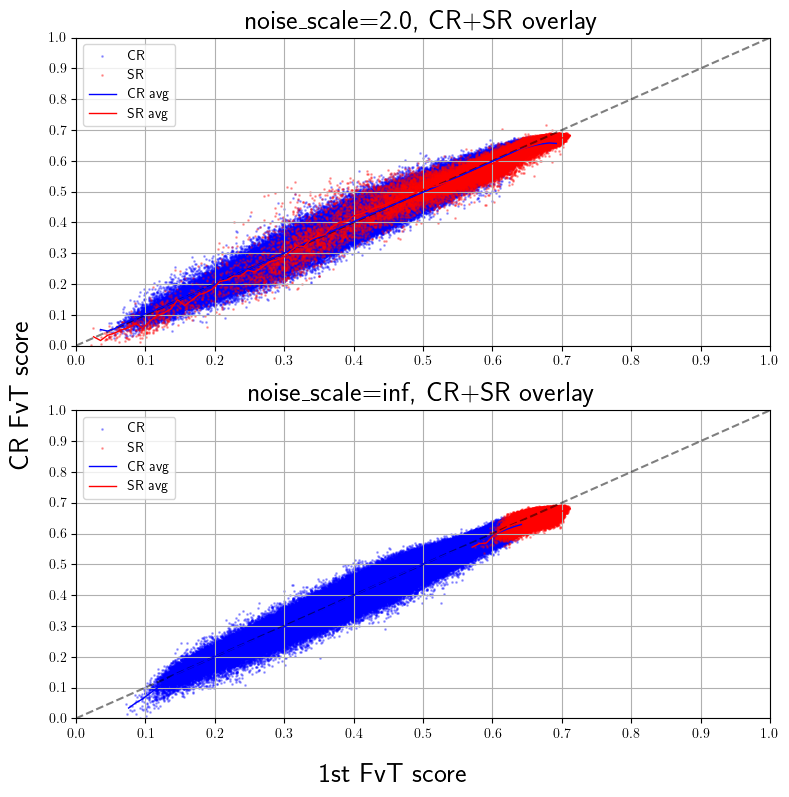

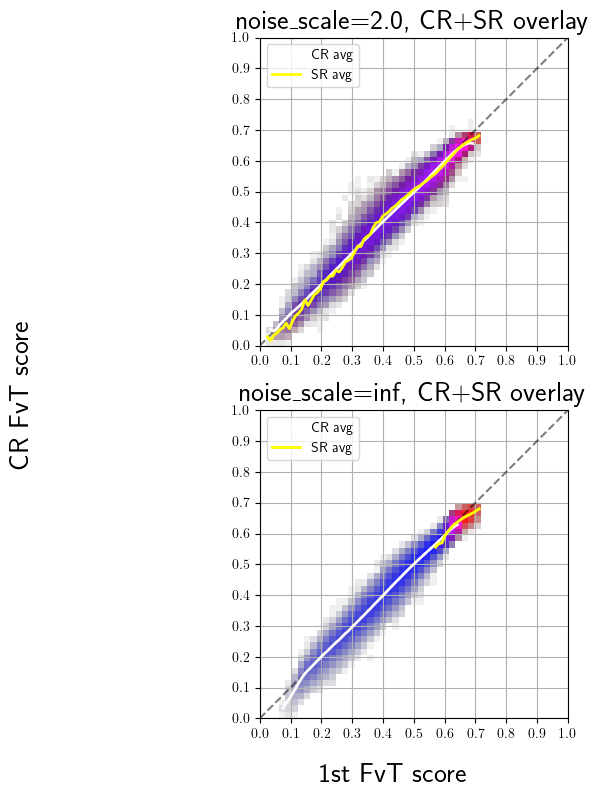

In [15]:
def scatter_fvt_fvt_overlay(ax: plt.Axes, base_fvt_scores_cr: np.ndarray, fvt_scores_cr: np.ndarray,
                          base_fvt_scores_sr: np.ndarray, fvt_scores_sr: np.ndarray,
                          fvt_avg_cr: np.ndarray, midpoints_cr: np.ndarray,
                          fvt_avg_sr: np.ndarray, midpoints_sr: np.ndarray):
    """Overlay CR and SR scatter plots."""
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.5)
    
    # Scatter plots with different colors and markers
    ax.scatter(base_fvt_scores_cr, fvt_scores_cr, alpha=0.3, s=1, color='blue', label='CR')
    ax.scatter(base_fvt_scores_sr, fvt_scores_sr, alpha=0.3, s=1, color='red', label='SR')
    
    # Average lines (thinner)
    ax.plot(midpoints_cr, fvt_avg_cr, color="blue", linewidth=1, label='CR avg')
    ax.plot(midpoints_sr, fvt_avg_sr, color="red", linewidth=1, label='SR avg')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

def hist_fvt_fvt_overlay(ax: plt.Axes, base_fvt_scores_cr: np.ndarray, fvt_scores_cr: np.ndarray,
                       base_fvt_scores_sr: np.ndarray, fvt_scores_sr: np.ndarray,
                       fvt_avg_cr: np.ndarray, midpoints_cr: np.ndarray,
                       fvt_avg_sr: np.ndarray, midpoints_sr: np.ndarray):
    """Overlay CR and SR 2D histograms."""
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.5)
    
    bins = np.linspace(0, 1, 50)
    
    # Create separate 2D histograms with higher contrast
    hist_cr, xedges, yedges = np.histogram2d(base_fvt_scores_cr, fvt_scores_cr, bins=(bins, bins))
    hist_sr, _, _ = np.histogram2d(base_fvt_scores_sr, fvt_scores_sr, bins=(bins, bins))
    
    # Apply log scale and normalize for better visibility
    hist_cr_log = np.log10(hist_cr + 1)  # +1 to avoid log(0)
    hist_sr_log = np.log10(hist_sr + 1)
    
    hist_cr_norm = hist_cr_log / (hist_cr_log.max() + 1e-10)
    hist_sr_norm = hist_sr_log / (hist_sr_log.max() + 1e-10)
    
    # Create more visible RGBA image
    rgba_image = np.zeros((len(bins)-1, len(bins)-1, 4))
    rgba_image[:, :, 0] = hist_sr_norm.T  # Red channel for SR
    rgba_image[:, :, 2] = hist_cr_norm.T  # Blue channel for CR
    rgba_image[:, :, 3] = np.clip(hist_cr_norm.T + hist_sr_norm.T, 0, 1)  # Combined alpha
    
    ax.imshow(rgba_image, extent=[0, 1, 0, 1], origin='lower', alpha=0.9)
    
    # Average lines (thinner and more visible)
    ax.plot(midpoints_cr, fvt_avg_cr, color="white", linewidth=2, label='CR avg', linestyle='-')
    ax.plot(midpoints_sr, fvt_avg_sr, color="yellow", linewidth=2, label='SR avg', linestyle='-')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

def plot_hash_results_overlay(hash_: str, 
                            base_fvt_scores_tst: np.ndarray, 
                            events_train: EventsData,
                            events_tst: EventsData, 
                            axs_scatter: plt.Axes, 
                            axs_hist: plt.Axes, 
                            plot_idx: int):
    """Analyze and plot overlaid results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    # Get region cuts and indices
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
    )
    CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
    SR_idx = SR_stats_tst >= SR_cut
    
    # Calculate FVT scores
    events_tst_CR = events_tst[CR_idx]
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    fvt_scores_tst_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].numpy()
    
    # Calculate correlations
    corr_CR = np.corrcoef(SR_stats_tst[CR_idx], fvt_scores_tst_CR)[0, 1]
    corr_SR = np.corrcoef(SR_stats_tst[SR_idx], fvt_scores_tst_SR)[0, 1]
    
    print(f"noise_scale = {noise_scale}")
    print(f"Corr CR: {corr_CR:.3f}")
    print(f"Corr SR: {corr_SR:.3f}")
    
    # Compute averages
    midpoints_cr, fvt_avg_cr = compute_avg_fvt_score(base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR)
    midpoints_sr, fvt_avg_sr = compute_avg_fvt_score(base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR)
    
    # Create overlaid plots
    axs_scatter[plot_idx].set_title(f"noise_scale={noise_scale}, CR+SR overlay")
    scatter_fvt_fvt_overlay(axs_scatter[plot_idx], 
                           base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR,
                           base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR,
                           fvt_avg_cr, midpoints_cr, fvt_avg_sr, midpoints_sr)
    
    axs_hist[plot_idx].set_title(f"noise_scale={noise_scale}, CR+SR overlay")
    hist_fvt_fvt_overlay(axs_hist[plot_idx],
                        base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR,
                        base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR,
                        fvt_avg_cr, midpoints_cr, fvt_avg_sr, midpoints_sr)

# Modified main loop
allowed_noise_scales = [np.inf, 2.0]
for seed in [5, 10, 15, 20, 25]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    base_fvt_scores_tst, base_fvt_scores_train = calculate_base_fvt_scores(SR_stats_hashes)

    # Create single column of plots (one per noise scale)
    fig_scatter, axs_scatter = plt.subplots(len(allowed_noise_scales), 1, figsize=(8, 4 * len(allowed_noise_scales)))
    fig_scatter.supxlabel("1st FvT score")
    fig_scatter.supylabel("CR FvT score")
    
    fig_hist, axs_hist = plt.subplots(len(allowed_noise_scales), 1, figsize=(8, 4 * len(allowed_noise_scales)))
    fig_hist.supxlabel("1st FvT score")
    fig_hist.supylabel("CR FvT score")
    
    # Handle single subplot case
    if len(allowed_noise_scales) == 1:
        axs_scatter = [axs_scatter]
        axs_hist = [axs_hist]
    
    # Process each hash
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        plot_hash_results_overlay(hash_, base_fvt_scores_tst, events_train, events_tst, axs_scatter, axs_hist, i)
    
    # Display results
    for fig in [fig_scatter, fig_hist]: 
        fig.tight_layout()
    plt.show()

In [ ]:
n_reps = 1000
cdf_mode = "mean"
storage = f"affine_correction_and_ks_poisson_bootstrap_n_reps={n_reps}_cdf_mode={cdf_mode}"

from tqdm import tqdm

n_reps = 1000
sig_level = 0.05
SR_size = 0.2
experiment_name = "CR_fvt_training_ensemble_max"

hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                    #  "signal_region": lambda x: x["4b_in_SR"] == SR_size
                                     }, 
                                     return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = []

np.random.seed(0)
for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    
    correction_results = CR_fvt_tinfo.aux_info[storage]
    
    alt_value_correction = correction_results["alt_value_correction"]
    null_values_correction = correction_results["null_values_correction"]
    alt_value_no_correction = correction_results["alt_value_no_correction"]
    null_values_no_correction = correction_results["null_values_no_correction"]
    p_value_correction = correction_results["p_value_correction"]
    p_value_no_correction = correction_results["p_value_no_correction"]
    
    results.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "SR_size": SR_size,
        "noise_scale": noise_scale,
        "p_value_correction": p_value_correction,
        "p_value_no_correction": p_value_no_correction,
        "alt_value_correction": alt_value_correction,
        "null_values_correction": null_values_correction,
        "alt_value_no_correction": alt_value_no_correction,
        "null_values_no_correction": null_values_no_correction,
        "correction_slope": correction_results["correction_slope"],
        "correction_intercept": correction_results["correction_intercept"],
        "stats_3b_mean": correction_results["stats_3b_mean"],
        "stats_3b_std": correction_results["stats_3b_std"],
    })

results_df = pd.DataFrame(results)

results_df["reject_null_correction"] = results_df["p_value_correction"] <= sig_level
results_df["reject_null_no_correction"] = results_df["p_value_no_correction"] <= sig_level
pd.set_option("display.max_rows", 100)
for signal_ratio in [0.0, 0.005, 0.0075, 0.01, 0.02]:
    print(f"signal_ratio = {signal_ratio}")
    tmp_df = results_df[results_df["signal_ratio"] == signal_ratio]
    tmp_df = tmp_df.groupby(["SR_size", "noise_scale"]).agg({
        "reject_null_correction": "mean",
        "reject_null_no_correction": "mean"
    })
    display(tmp_df)